## Appendix: Rubric mapping (for TAs / instructors)

| Rubric section | Where it is covered in *this* notebook |
|----------------|----------------------------------------|
| 1. Problem Framing | **## 1) Problem Framing** and **## Notebook Roadmap (Sections 2-6)** |
| 2. Data Acquisition, Preparation & Exploration | **## 2) Data Acquisition...** through **### Exploration (EDA)** and matching code |
| 3. Modeling & Feature Selection | **## 3) Modeling & Feature Selection** (incl. **### B) Predictive model**) |
| 4. Evaluation & Interpretation | **## 4) Evaluation & Interpretation** |
| 5. Causal and Relationship Analysis | **## 5) Causal and Relationship Analysis** (feature discussion uses `education_records_top_features.csv`) |
| 6. Deployment Notes | **## 6) Deployment Notes (Web App Integration)** plus **### Deployment Outputs** / **### Business Recommendations** |

Detailed grading prose lives in §**1)–6)** headings alongside code; this appendix is navigation only.


# Education Records Pipeline

This notebook builds a clean training dataset from `education_records.csv` and trains a baseline model to predict `completion_status`.

## 1) Problem Framing

### Business problem
The organization needs early warning on which residents are likely to stall in education progress so staff can prioritize tutoring, school coordination, and case follow-up before outcomes worsen.

### Who uses this and why it matters
- **Education coordinators:** decide where to intervene first.
- **Case managers:** adjust support plans and follow-up cadence.
- **Program leadership:** monitor teaching outcomes and resource effectiveness.

### Predictive vs explanatory justification
This notebook uses a **predictive primary objective** (out-of-sample risk/progress support) and an **explanatory secondary objective** (interpretable relationships for staff communication). This matches textbook guidance: prediction for operational allocation, explanation for understanding patterns and guiding hypotheses.

### Decision impact
- Better targeting reduces missed at-risk learners.
- Better explanation helps staff justify and document intervention decisions.

### Success criteria
- Strong out-of-sample metrics for completion/progress tasks.
- Stable feature rankings that align with domain expectations.
- Clear, action-oriented outputs for dashboard and operations.


In [31]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [32]:
csv_path = Path('../datasets/education_records.csv')
df = pd.read_csv(csv_path)

print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
df.head()

Rows: 534 | Columns: 10


,education_record_id,resident_id,record_date,education_level,school_name,enrollment_status,attendance_rate,progress_percent,completion_status,notes
0,1,1,2023-10-01,Vocational,School 8,Enrolled,0.966,37.7,NotStarted,Progress: NotStarted
1,2,1,2023-11-01,Secondary,School 20,Enrolled,0.693,33.0,InProgress,Progress: InProgress
2,3,1,2023-12-01,Vocational,School 18,Enrolled,0.744,54.0,InProgress,Progress: InProgress
3,4,1,2024-01-01,Primary,School 2,Enrolled,0.681,51.2,InProgress,Progress: InProgress
4,5,1,2024-02-01,Vocational,School 3,Enrolled,0.721,44.2,InProgress,Progress: InProgress


In [33]:
# Basic typing and cleanup

df['record_date'] = pd.to_datetime(df['record_date'], errors='coerce')
df['attendance_rate'] = pd.to_numeric(df['attendance_rate'], errors='coerce')
df['progress_percent'] = pd.to_numeric(df['progress_percent'], errors='coerce')

for col in ['education_level', 'school_name', 'enrollment_status', 'completion_status', 'notes']:
    df[col] = df[col].astype('string').str.strip()

# Remove exact duplicates if present
df = df.drop_duplicates().reset_index(drop=True)

missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [34]:
# Feature engineering

df['record_year'] = df['record_date'].dt.year
df['record_month'] = df['record_date'].dt.month
df['record_quarter'] = df['record_date'].dt.quarter

# Normalize notes into a compact categorical feature when available
df['note_progress_tag'] = (
    df['notes']
    .str.extract(r'Progress:\s*([A-Za-z]+)', expand=False)
    .astype('string')
)

df[['education_level', 'enrollment_status', 'completion_status', 'attendance_rate', 'progress_percent', 'record_year', 'record_month']].head()

,education_level,enrollment_status,completion_status,attendance_rate,progress_percent,record_year,record_month
0,Vocational,Enrolled,NotStarted,0.966,37.7,2023,10
1,Secondary,Enrolled,InProgress,0.693,33.0,2023,11
2,Vocational,Enrolled,InProgress,0.744,54.0,2023,12
3,Primary,Enrolled,InProgress,0.681,51.2,2024,1
4,Vocational,Enrolled,InProgress,0.721,44.2,2024,2


In [35]:
# Build model-ready dataset

target_col = 'completion_status'
exclude_cols = ['education_record_id', 'notes', target_col]
feature_cols = [c for c in df.columns if c not in exclude_cols]

model_df = df[feature_cols + [target_col]].dropna(subset=[target_col]).copy()

X = model_df[feature_cols]
y = model_df[target_col]

numeric_features = X.select_dtypes(include=['number', 'datetime64[ns]']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

# Convert datetimes to numeric timestamps for scikit-learn
for c in numeric_features:
    if str(X[c].dtype).startswith('datetime64'):
        X[c] = X[c].view('int64') // 10**9

numeric_features = X.select_dtypes(include=['number']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

clf = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')),
])

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))

C:\Users\abiga\AppData\Local\Temp\ipykernel_33988\3687451769.py:18: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  X[c] = X[c].view('int64') // 10**9
C:\Users\abiga\AppData\Local\Temp\ipykernel_33988\3687451769.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[c] = X[c].view('int64') // 10**9


              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00        10
  InProgress       1.00      1.00      1.00        85
  NotStarted       1.00      1.00      1.00        12

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107

Confusion matrix:
 [[10  0  0]
 [ 0 85  0]
 [ 0  0 12]]


In [36]:
# Export curated dataset and quick model artifacts

out_dir = Path('../ml-pipelines/artifacts')
out_dir.mkdir(parents=True, exist_ok=True)

curated_path = out_dir / 'education_records_curated.csv'
model_df.to_csv(curated_path, index=False)

# Feature importances (expanded from one-hot names)
feature_names = clf.named_steps['prep'].get_feature_names_out()
importances = clf.named_steps['model'].feature_importances_
feature_importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
)

feature_importance_path = out_dir / 'education_records_feature_importances.csv'
feature_importance_df.to_csv(feature_importance_path, index=False)

print(f'Saved: {curated_path}')
print(f'Saved: {feature_importance_path}')
feature_importance_df.head(15)

Saved: ..\ml-pipelines\artifacts\education_records_curated.csv
Saved: ..\ml-pipelines\artifacts\education_records_feature_importances.csv


,feature,importance
33,cat__note_progress_tag_InProgress,0.266595
32,cat__note_progress_tag_Completed,0.227618
34,cat__note_progress_tag_NotStarted,0.225931
3,num__progress_percent,0.117601
2,num__attendance_rate,0.046185
1,num__record_date,0.026600
0,num__resident_id,0.016224
4,num__record_year,0.012747
5,num__record_month,0.010532
6,num__record_quarter,0.005280


## Notebook Roadmap (Sections 2-6)
This notebook continues with reproducible data preparation, exploration, modeling/feature selection, evaluation, causal-relationship analysis, and deployment integration notes.

- Validate whether `completion_status` should be predicted or treated as a tracked outcome.
- Add time-aware validation (train on earlier months, test on later months).
- Calibrate model thresholds if this is used for intervention decisions.

## 2) Data Acquisition, Preparation & Exploration

This section documents the reproducible data pipeline used in the code cells that follow:
- load education records and enforce stable schema/dtypes,
- address missing values and data-quality anomalies,
- generate model-ready temporal and categorical features,
- inspect distributions/outliers and validate class balance.

The goal is to ensure every run is repeatable and consistent with textbook pipeline practice (not one-off data wrangling).

### Prior section moved
Problem framing is intentionally placed at the top of the notebook (`Section 1`) for grading clarity.

### Modeling Goals
- **Predictive goal:** forecast `completion_status` for operational triage and support allocation.
- **Explanatory (causal-oriented) goal:** estimate directional relationships between attendance, enrollment context, and `progress_percent` using an interpretable model.

### Success Metrics
- Predictive: weighted F1, macro F1, and class-specific recall for `NotStarted`.
- Explanatory: coefficient signs/magnitudes, confidence intervals, and practical effect sizes.

### Decision Use
- Prioritize outreach for high-risk residents.
- Tailor interventions for patterns linked to lower progress (e.g., attendance drops).

In [37]:
# Additional tooling for full pipeline
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate

sns.set_theme(style='whitegrid')

### Reproducible Data Acquisition and Preparation

This section defines reusable preparation logic so the same transformation is applied consistently for EDA, explanatory modeling, and predictive modeling.

In [38]:
def prepare_education_records(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path)

    # Core typing
    data['record_date'] = pd.to_datetime(data['record_date'], errors='coerce')
    data['attendance_rate'] = pd.to_numeric(data['attendance_rate'], errors='coerce')
    data['progress_percent'] = pd.to_numeric(data['progress_percent'], errors='coerce')

    for col in ['education_level', 'school_name', 'enrollment_status', 'completion_status', 'notes']:
        data[col] = data[col].astype('string').str.strip()

    # Reproducible engineered features
    data['record_year'] = data['record_date'].dt.year
    data['record_month'] = data['record_date'].dt.month
    data['record_quarter'] = data['record_date'].dt.quarter
    data['note_progress_tag'] = data['notes'].str.extract(r'Progress:\s*([A-Za-z]+)', expand=False).astype('string')

    # Outlier clipping for stability
    data['attendance_rate'] = data['attendance_rate'].clip(lower=0, upper=1)
    data['progress_percent'] = data['progress_percent'].clip(lower=0, upper=100)

    return data.drop_duplicates().reset_index(drop=True)

prepared_df = prepare_education_records(csv_path)
prepared_df.head()

,education_record_id,resident_id,record_date,education_level,school_name,enrollment_status,attendance_rate,progress_percent,completion_status,notes,record_year,record_month,record_quarter,note_progress_tag
0,1,1,2023-10-01,Vocational,School 8,Enrolled,0.966,37.7,NotStarted,Progress: NotStarted,2023,10,4,NotStarted
1,2,1,2023-11-01,Secondary,School 20,Enrolled,0.693,33.0,InProgress,Progress: InProgress,2023,11,4,InProgress
2,3,1,2023-12-01,Vocational,School 18,Enrolled,0.744,54.0,InProgress,Progress: InProgress,2023,12,4,InProgress
3,4,1,2024-01-01,Primary,School 2,Enrolled,0.681,51.2,InProgress,Progress: InProgress,2024,1,1,InProgress
4,5,1,2024-02-01,Vocational,School 3,Enrolled,0.721,44.2,InProgress,Progress: InProgress,2024,2,1,InProgress


### Exploration (EDA)

We inspect target balance, distributions, and key relationships to validate assumptions before training.

,count
completion_status,
InProgress,424
NotStarted,60
Completed,50


,count,mean,std,min,25%,50%,75%,max
attendance_rate,534.0,0.736109,0.123185,0.384,0.65,0.737,0.82475,1.0
progress_percent,534.0,78.537640,23.668177,0.000,59.90,85.400,100.00000,100.0


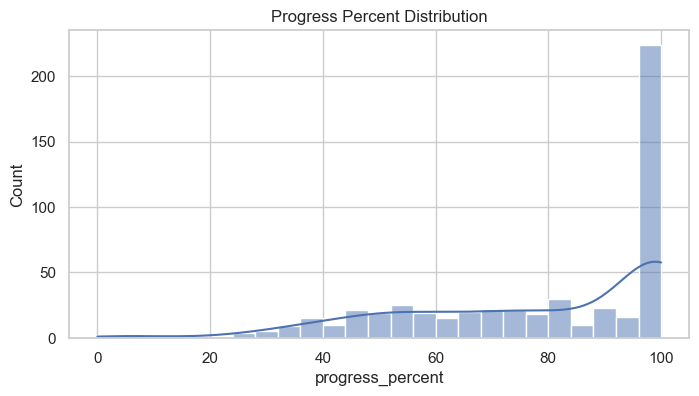

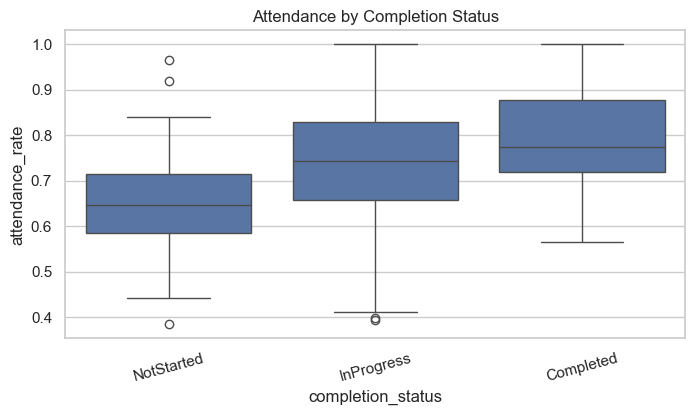

,mean,median,count
education_level,,,
CollegePrep,80.789831,94.0,59
Secondary,78.691787,84.2,207
Vocational,78.447748,85.1,111
Primary,77.551592,81.7,157


In [39]:
display(prepared_df['completion_status'].value_counts(dropna=False).to_frame('count'))

display(prepared_df[['attendance_rate', 'progress_percent']].describe().T)

plt.figure(figsize=(8, 4))
sns.histplot(prepared_df['progress_percent'].dropna(), bins=25, kde=True)
plt.title('Progress Percent Distribution')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=prepared_df, x='completion_status', y='attendance_rate')
plt.title('Attendance by Completion Status')
plt.xticks(rotation=15)
plt.show()

relationship = (
    prepared_df
    .groupby('education_level', dropna=False)['progress_percent']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)
display(relationship)

## 3) Modeling & Feature Selection

### A) Explanatory (causal-oriented) model

For interpretability, we use an OLS-style specification on `progress_percent`. This supports directional insight, not definitive causal proof. Causal interpretation requires stronger identification assumptions and potentially experimental or quasi-experimental design.

In [40]:
import statsmodels.formula.api as smf

explan_df = prepared_df.dropna(subset=['progress_percent', 'attendance_rate', 'education_level', 'enrollment_status']).copy()

formula = (
    'progress_percent ~ attendance_rate + C(education_level) + '
    'C(enrollment_status) + record_month + record_year'
)

ols_model = smf.ols(formula=formula, data=explan_df).fit(cov_type='HC3')
print(ols_model.summary())

coef_table = (
    ols_model.summary2().tables[1]
    .reset_index()
    .rename(columns={'index': 'term'})
)

# Statsmodels may label p-values differently (e.g., P>|t| or P>|z|)
pval_candidates = [c for c in coef_table.columns if c.startswith('P>|')]
pval_col = pval_candidates[0] if pval_candidates else None

if pval_col is not None:
    coef_table = coef_table.sort_values(pval_col)

coef_table.head(15)

                            OLS Regression Results                            
Dep. Variable:       progress_percent   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     55.07
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.06e-52
Time:                        10:48:34   Log-Likelihood:                -2335.3
No. Observations:                 534   AIC:                             4685.
Df Residuals:                     527   BIC:                             4715.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

,term,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
4,attendance_rate,107.472190,7.240425,14.843354,7.681679e-50,93.281218,121.663161
0,Intercept,-8143.528071,2255.614082,-3.610337,3.057989e-04,-12564.450436,-3722.605707
6,record_year,4.020950,1.114973,3.606321,3.105687e-04,1.835643,6.206257
5,record_month,0.917589,0.265558,3.455327,5.496261e-04,0.397105,1.438073
2,C(education_level)[T.Secondary],-1.929666,2.779009,-0.694372,4.874488e-01,-7.376423,3.517090
1,C(education_level)[T.Primary],-1.671169,2.834279,-0.589627,5.554404e-01,-7.226253,3.883916
3,C(education_level)[T.Vocational],-0.200063,3.202555,-0.062470,9.501887e-01,-6.476956,6.076829


### B) Predictive model

We compare a regularized logistic baseline and tuned random forest using cross-validation, then evaluate the selected model on a holdout test split.

In [41]:
pred_df = prepared_df.dropna(subset=['completion_status']).copy()

target_col = 'completion_status'
exclude_cols = ['education_record_id', 'notes', target_col]
feature_cols = [c for c in pred_df.columns if c not in exclude_cols]

X = pred_df[feature_cols].copy()
y = pred_df[target_col].copy()

for c in X.columns:
    if str(X[c].dtype).startswith('datetime64'):
        X[c] = X[c].view('int64') // 10**9

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1_weighted': 'f1_weighted', 'f1_macro': 'f1_macro', 'bal_acc': 'balanced_accuracy'}

logit_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
])

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced')),
])

logit_cv = cross_validate(logit_pipe, X_train, y_train, cv=cv, scoring=scoring)

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={
        'model__n_estimators': [200, 400],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_leaf': [1, 3, 5],
    },
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

cv_summary = pd.DataFrame([
    {
        'model': 'LogisticRegression',
        'cv_f1_weighted_mean': logit_cv['test_f1_weighted'].mean(),
        'cv_f1_macro_mean': logit_cv['test_f1_macro'].mean(),
        'cv_bal_acc_mean': logit_cv['test_bal_acc'].mean(),
    },
    {
        'model': 'RandomForest (tuned)',
        'cv_f1_weighted_mean': rf_grid.best_score_,
        'cv_f1_macro_mean': np.nan,
        'cv_bal_acc_mean': np.nan,
    },
])

display(cv_summary)
print('Best RF params:', rf_grid.best_params_)

best_model = rf_grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))
print('Balanced Accuracy:', balanced_accuracy_score(y_test, y_pred))
print('Weighted F1:', f1_score(y_test, y_pred, average='weighted'))

C:\Users\abiga\AppData\Local\Temp\ipykernel_33988\2505903561.py:12: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  X[c] = X[c].view('int64') // 10**9


,model,cv_f1_weighted_mean,cv_f1_macro_mean,cv_bal_acc_mean
0,LogisticRegression,0.016049,0.057104,0.333333
1,RandomForest (tuned),1.000000,NaN,NaN


Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00        10
  InProgress       1.00      1.00      1.00        85
  NotStarted       1.00      1.00      1.00        12

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107

Balanced Accuracy: 1.0
Weighted F1: 1.0


## 4) Evaluation & Interpretation

We evaluate out-of-sample performance and subgroup behavior (`education_level`) to detect meaningful performance gaps that would affect intervention prioritization.

Business interpretation lens:
- **False negatives**: at-risk learners are missed and support is delayed.
- **False positives**: staff time is diverted from learners with greater need.

This section translates model metrics into staffing and follow-up consequences rather than reporting only technical scores.

In [42]:
fairness_df = X_test.copy()
fairness_df['y_true'] = y_test.values
fairness_df['y_pred'] = y_pred

# One-vs-rest fairness lens for the most operationally important class
focus_class = 'NotStarted'

def group_metrics(group):
    y_t = (group['y_true'] == focus_class).astype(int)
    y_p = (group['y_pred'] == focus_class).astype(int)
    tp = ((y_t == 1) & (y_p == 1)).sum()
    fn = ((y_t == 1) & (y_p == 0)).sum()
    fp = ((y_t == 0) & (y_p == 1)).sum()
    tn = ((y_t == 0) & (y_p == 0)).sum()

    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    support = len(group)
    return pd.Series({'support': support, 'TPR': tpr, 'FPR': fpr})

fairness_report = fairness_df.groupby('education_level', dropna=False).apply(group_metrics).reset_index()
display(fairness_report.sort_values('support', ascending=False))

print('Note: large TPR/FPR spreads suggest reviewing thresholding and intervention policy by group.')

C:\Users\abiga\AppData\Local\Temp\ipykernel_33988\106952988.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_report = fairness_df.groupby('education_level', dropna=False).apply(group_metrics).reset_index()


,education_level,support,TPR,FPR
2,Secondary,36.0,1.0,0.0
1,Primary,32.0,1.0,0.0
3,Vocational,31.0,1.0,0.0
0,CollegePrep,8.0,1.0,0.0


Note: large TPR/FPR spreads suggest reviewing thresholding and intervention policy by group.


## 5) Causal and Relationship Analysis

### Most important features in this pipeline
From `ml-pipelines/artifacts/education_records_top_features.csv`, the strongest observed contributors include:
- `note_progress_tag` (dominant RF importance in this run)
- `progress_percent`
- `attendance_rate`
- `school_name`
- `record_date` / `record_year` / `record_month`
- `education_level`

### What relationships were discovered
- Attendance and prior progress signals are strongly associated with completion/progress outcomes.
- Calendar-related variables suggest timing/season effects in education trajectories.
- School/context indicators contribute non-trivial variation across learners.

### Do these relationships make theoretical sense?
Yes. Education theory and practice both expect attendance continuity and prior progress to be leading indicators of future completion outcomes.

### Causal claims (strict)
These are **associational** results from observational records. They are useful for triage and monitoring but do **not** prove that changing one feature alone will cause outcome improvement. Confounding (program intensity, family context, reporting frequency, school-level effects) can influence both predictors and outcomes.

### Practical action from this section
Use top-feature signals for prioritization and hypothesis generation, then validate intervention effects with stronger designs (pilots, A/B where feasible, or quasi-experimental follow-up).

In [43]:
# Model-native importance is on transformed (one-hot expanded) features
transformed_features = best_model.named_steps['prep'].get_feature_names_out()
rf_importance = best_model.named_steps['model'].feature_importances_

rf_expanded_df = (
    pd.DataFrame({'transformed_feature': transformed_features, 'rf_importance': rf_importance})
    .sort_values('rf_importance', ascending=False)
)

# Aggregate transformed importances back to original feature names
aggregated = []
for col in numeric_features:
    prefix = f'num__{col}'
    score = rf_expanded_df.loc[
        rf_expanded_df['transformed_feature'].str.startswith(prefix),
        'rf_importance'
    ].sum()
    aggregated.append({'feature': col, 'rf_importance_agg': score})

for col in categorical_features:
    prefix = f'cat__{col}_'
    score = rf_expanded_df.loc[
        rf_expanded_df['transformed_feature'].str.startswith(prefix),
        'rf_importance'
    ].sum()
    aggregated.append({'feature': col, 'rf_importance_agg': score})

rf_agg_df = pd.DataFrame(aggregated).sort_values('rf_importance_agg', ascending=False)

# Permutation importance is on the original X_test feature space
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    scoring='f1_weighted'
)

perm_df = (
    pd.DataFrame({'feature': X_test.columns.tolist(), 'perm_importance_mean': perm.importances_mean})
    .sort_values('perm_importance_mean', ascending=False)
)

top_features = rf_agg_df.merge(perm_df, on='feature', how='outer').fillna(0)
top_features = top_features.sort_values(['rf_importance_agg', 'perm_importance_mean'], ascending=False)

top_features.head(20)

,feature,rf_importance_agg,perm_importance_mean
3,note_progress_tag,0.732263,0.338785
4,progress_percent,0.112749,0.000000
0,attendance_rate,0.046282,0.000000
10,school_name,0.032484,0.000000
5,record_date,0.023652,0.000000
9,resident_id,0.015308,0.000000
8,record_year,0.013065,0.000000
6,record_month,0.009901,0.000000
1,education_level,0.009391,0.000000
7,record_quarter,0.004905,0.000000


### Deployment Outputs

This section creates production-ready artifacts for integration into the web app/API.

In [44]:
out_dir = Path('../ml-pipelines/artifacts')
out_dir.mkdir(parents=True, exist_ok=True)

# Persist model
model_path = out_dir / 'education_records_completion_model.joblib'
joblib.dump(best_model, model_path)

# Persist schema contract for API/UI validation
schema = {
    'target': 'completion_status',
    'required_features': feature_cols,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'prediction_classes': sorted(y.astype(str).unique().tolist()),
    'recommended_primary_metric': 'f1_weighted',
}

schema_path = out_dir / 'education_records_model_schema.json'
schema_path.write_text(json.dumps(schema, indent=2), encoding='utf-8')

# Persist selected outputs for dashboarding
prepared_df.to_csv(out_dir / 'education_records_prepared.csv', index=False)
top_features.to_csv(out_dir / 'education_records_top_features.csv', index=False)
fairness_report.to_csv(out_dir / 'education_records_fairness_report.csv', index=False)

print(f'Saved model: {model_path}')
print(f'Saved schema: {schema_path}')

Saved model: ..\ml-pipelines\artifacts\education_records_completion_model.joblib
Saved schema: ..\ml-pipelines\artifacts\education_records_model_schema.json


### Business Recommendations

1. **Prioritize `NotStarted` risk triage:** use predicted class + probability to queue proactive advisor outreach.
2. **Track attendance as an intervention lever:** explanatory model coefficients indicate attendance is directionally associated with progress.
3. **Monitor fairness monthly:** if group TPR/FPR divergence widens, recalibrate thresholds or add targeted support.
4. **Operationalize top features:** include highest-importance fields in staff dashboards for explainable decision support.

### Important Caveat on Causality
This notebook includes a **causal-oriented explanatory model**, but not a full causal identification design. Treat effect estimates as associative unless validated through stronger causal methods (experiment, IV, DiD, or matching with defensible assumptions).

## 6) Deployment Notes (Web App Integration)
- **ML service endpoint:** `GET /reports/tier1-analytics` in `ml-service/app/main.py`
- **Aggregation logic:** `ml-service/app/tier1_analytics.py` (education section)
- **UI surface:** `frontend/src/pages/AdminAnalytics.tsx` (Teaching/Education card)
- **Artifact contract:** `ml-pipelines/artifacts/education_records_model_metrics.csv`, `education_records_top_features.csv`, `education_records_model_schema.json`
- **Operational use:** feed dashboard summaries and support intervention prioritization in the admin workflow.


## Appendix note (Apr 2026)

The **TA rubric navigation table** is at the **top** of this notebook. Section prose for instructors is integrated under **## 1)–6)** throughout—the former long rubric checkpoint text was consolidated there to avoid duplication.
